In [ ]:
from topological_insulator import Problem

In [ ]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [ ]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC, t_1, delta):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                # parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.2 * t_1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1 - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1 + delta
            except:
                pass
        # print(parser)   

In [ ]:
location = "bulk"
Delta_SOC = -5

In [34]:
dE_list = []
t_list = [1, -1]
deltas = np.linspace(-2, 2, 15)
for t in t_list:
    for delta in deltas:
        # delta = eigenvalue_dict["delta"]
        print("")
        print(f"Running case for: delta/t = {delta/t}")
        problem = Problem(structure_path=structure_path, structure_name=structure_name)
        set_eigenvalues(problem, Delta_SOC, t, delta)
        problem.setup(
            N_r = 10,
            N_k = 200,
            location = location,
            BZ = "reduced"
        )
        problem.run(
            H_type="reciprocal"
        )
        invariants = problem.hamiltonian[location]["topological_invariants"]
        dE = invariants.get_band_gap(23, 21, only_dE=True)
        dE_list.append(dE)
        # results[n] = problem


Running case for: delta/t = -2.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t = -1.7142857142857144
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t = -1.4285714285714286
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t = -1.1428571428571428
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t = -0.8571428571428572
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigen

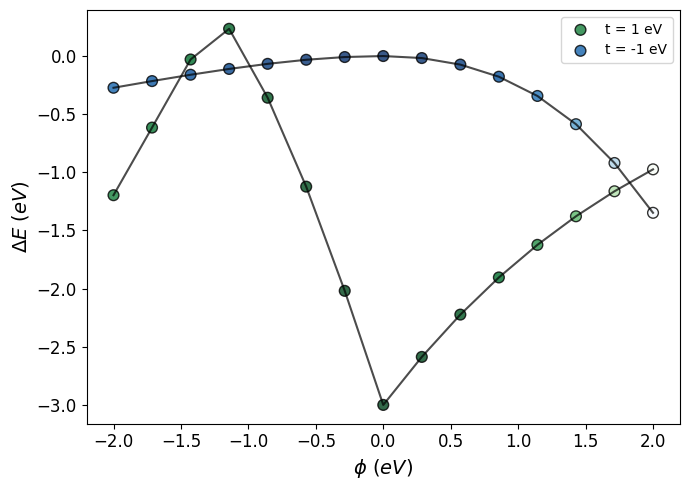

In [35]:
from matplotlib import pyplot as plt

# Apply a nicer style
# plt.style.use("seaborn-v0_8-whitegrid")
n = len(dE_list)//2
# Create scatter plot with styling
plt.figure(figsize=(7, 5))
plt.scatter(
    deltas, dE_list[:n],
    c=dE_list[n:], cmap="Greens",  # color mapping by values
    s=60, alpha=0.8, edgecolors="k", label= f"t = 1 eV"
)
plt.scatter(
    deltas, dE_list[n:],
    c=dE_list[n:], cmap="Blues",  # color mapping by values
    s=60, alpha=0.8, edgecolors="k", label= f"t = -1 eV"
)

plt.plot(
    deltas, dE_list[:n],
    color="black", linewidth=1.5, alpha=0.7, zorder=1
)
plt.plot(
    deltas, dE_list[n:],
    color="black", linewidth=1.5, alpha=0.7, zorder=1
)

# Labels and title
plt.xlabel(r"$\phi \ (eV)$", fontsize=14)
plt.ylabel(r"$\Delta E \ (eV)$", fontsize=14)
# plt.title("Energy Difference vs. Delta", fontsize=16, pad=15)

# # Colorbar for reference
# cbar = plt.colorbar()
# cbar.set_label(r"$t (eV)$", fontsize=12)

# Improve tick sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.legend()
plt.show()


In [40]:
delta = deltas[3]
print(delta)

-1.1428571428571428


In [ ]:
j_3_2 = [i for i in range(9, 23)]
bands = [22, 23]

problem = Problem(structure_path=structure_path, structure_name=structure_name)
set_eigenvalues(problem, Delta_SOC, 1, delta)
problem.setup(
    N_r = 10,
    N_k = 400,
    location = location,
    BZ = "reduced"
)
problem.run(
    H_type="reciprocal"
)
tb_bulk = problem.hamiltonian[location]["tight_binding"]
invariants = problem.hamiltonian[location]["topological_invariants"]
g = problem.geometry
dE, E_0, E_1 = invariants.get_band_gap(23, 21, only_dE=False)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


0.23420898618849506


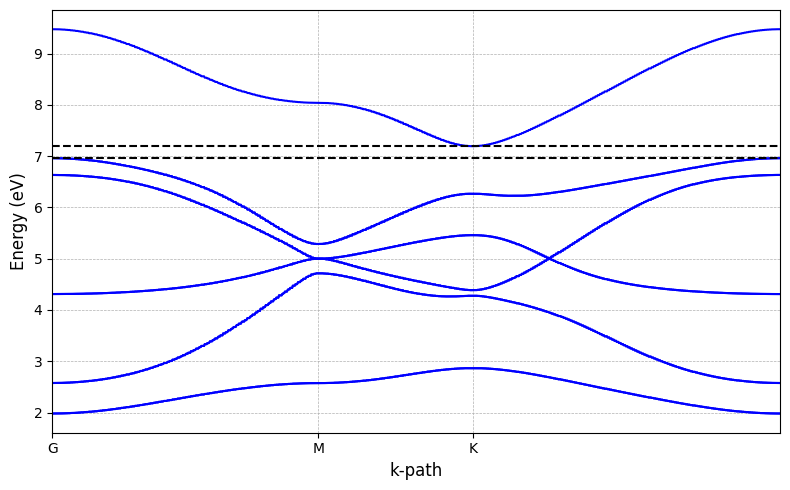

In [39]:
print(dE)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])

In [42]:
Z2 = invariants.Z2_invariant(bands=[22, 23], print_deltas=True)
print(Z2)

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = 1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
1
